# Search-9-Metaheuristiques : Optimisation avec MEALPy

**Navigation** : [<< Recherche locale](Search-4-LocalSearch.ipynb) | [Index](../README.md) | [App-1-NQueens >>](../Applications/App-1-NQueens.ipynb)

## Metaheuristiques : PSO, ABC, SA et au-dela

Ce notebook explore les **metaheuristiques**, une famille d'algorithmes d'optimisation inspires de la nature (evolution, essaims, physique) pour resoudre des problemes d'optimisation difficiles. Nous utiliserons la bibliotheque **MEALPy** qui implemente plus de 200 algorithmes.

### Objectifs d'apprentissage

A la fin de ce notebook, vous saurez :
1. **Comprendre** les principes fondamentaux des metaheuristiques et leurs categories (Evolution-based, Swarm-based, Physics-based, Human-based)
2. **Comparer** les performances de differents algorithmes sur des problemes de benchmark
3. **Appliquer** mealpy pour resoudre des problemes d'optimisation reels
4. **Analyser** la convergence et les parametres des algorithmes

### Prerequis
- Notebook Search-4-LocalSearch (Hill Climbing, Simulated Annealing)
- Python 3.10+ : numpy, matplotlib
- Notions de base en optimisation (fonction objectif, minimiseur)

### Duree estimee : 1h30

In [4]:
# Imports
import sys
import time
import math
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

%matplotlib inline

# Imports MEALPy 3.0.2
from mealpy import ParameterGrid
from mealpy import PSO, ABC, SA, BRO, GWO, WOA, GA, DE, Problem
from mealpy.utils.space import FloatVar

# Configuration
np.random.seed(42)

print("Environnement pret pour les metaheuristiques.")
print(f"MEALPy 3.0.2 importe avec succes.")

Environnement pret pour les metaheuristiques.
MEALPy 3.0.2 importe avec succes.


## 1. Introduction aux Metaheuristiques (~15 min)

### Qu'est-ce qu'une metaheuristique ?

Une **metaheuristique** est un algorithme d'optimisation qui guide un sous-probleme heuristique vers une solution optimale (ou proche de l'optimal). Contrairement aux algorithmes exacts, les metaheuristiques ne garantissent pas l'optimalite mais sont souvent efficaces sur des problemes difficiles.

**Caracteristiques cles** :
- **Sans derivees** : ne necessitent pas de calculer les gradients
- **Iteratives** : ameliorent progressivement la solution
- **Stochastiques** : utilisent l'aleatoire pour explorer l'espace
- **Generiques** : applicables a de nombreux problemes

### Classification des metaheuristiques

| Categorie | Inspiration | Exemples |
|-----------|-------------|----------|
| **Evolution-based** | Theorie de l'evolution, genetique | GA, DE, ES |
| **Swarm-based** | Comportements collectifs (essaims) | PSO, ABC, ACO, GWO |
| **Physics-based** | Loi physique | SA, GRAVITY, ELECTRO |
| **Human-based** | Comportement humain | BRO, TS, CA |

In [5]:
# Verification de MEALPy
try:
    import mealpy
    print(f"MEALPy version: {mealpy.__version__}")
    print(f"Nombre d'algorithmes disponibles: > 200")
except ImportError:
    print("MEALPy non installe. Installation...")
    print("Commande: pip install mealpy")

MEALPy version: 3.0.2
Nombre d'algorithmes disponibles: > 200


### Exploration vs Exploitation

Toute metaheuristique doit equilibrer deux forces opposes :

| Aspect | Exploration | Exploitation |
|--------|-------------|---------------|
| **Objectif** | Decouvrir de nouvelles regions de l'espace | Affiner les solutions prometteuses |
| **Risque** | Trop -> random search, lente convergence | Trop -> optimum local |
| **Analogie** | Chercher dans toute la maison | Chercher dans la piece ou on a perdu |

Le **succes d'une metaheuristique** depend de sa capacite a :
1. Explorer largement au debut (eviter les optima locaux)
2. Exploiter intensivement a la fin (converger vers l'optimum)
3. Adapter l'equilibre pendant la recherche

> **Theoreme No Free Lunch** : Aucun algorithme n'est optimal pour tous les problemes. Le choix depend de la structure du probleme.

## 2. La librairie MEALPy (~10 min)

### Presentation de MEALPy

**MEALPy** (Meta-Heuristic Algorithms in Python) est une bibliotheque qui implemente plus de **200 algorithmes** d'optimisation metaheuristiques avec une API unifiee.

**Installation** :
```bash
pip install mealpy>=3.0
```

### API standard (MEALPy 3.0.2)

Tous les algorithmes suivent le meme schema :

```python
from mealpy import Problem, Algorithme
from mealpy.utils.space import FloatVar

# Definir le probleme avec FloatVar
bounds = [FloatVar(lb=-10, ub=10), FloatVar(lb=-10, ub=10)]
problem = Problem(
    bounds=bounds,         # Liste de FloatVar definissant les bornes
    minmax="min",          # Minimisation ou maximisation
    obj_func=ma_fonction   # Fonction objectif
)

# Creer et executer l'algorithme
model = Algorithme(epoch=100, pop_size=50)
result = model.solve(problem)
```

### Parametres principaux

| Parametre | Signification | Valeur typique |
|-----------|---------------|----------------|
| **epoch** | Nombre d'iterations | 100-1000 |
| **pop_size** | Taille de la population | 20-100 |
| **bounds** | Liste de FloatVar (lb, ub) | Problemes-dependent |
| **minmax** | "min" ou "max" | "min" le plus souvent |

In [ ]:
# Exemple simple : optimiser une fonction quadratique
def simple_quadratic(solution):
    """Fonction quadratique simple : f(x) = sum(x^2)."""
    return np.sum(solution**2)

# Definir le probleme (MEALPy 3.0.2 API)
bounds = [FloatVar(lb=-10, ub=10), FloatVar(lb=-10, ub=10)]
problem = Problem(
    bounds=bounds,
    minmax="min",
    obj_func=simple_quadratic
)

# Resoudre avec PSO
model = PSO.OriginalPSO(epoch=50, pop_size=20)
result = model.solve(problem)

print("Resultat PSO sur fonction quadratique:")
print(f"  Solution: {result.solution.round(4)}")
print(f"  Objectif: {result.target.fitness:.6f}")
print(f"  Optimal attendu: [0, 0] avec f=0")

2026/03/07 07:35:17 PM, INFO, mealpy.swarm_based.PSO.OriginalPSO: OriginalPSO(epoch=50, pop_size=20, c1=2.05, c2=2.05, w=0.4)


2026/03/07 07:35:17 PM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 1, Current best: 0.5405868149971537, Global best: 0.5405868149971537, Runtime: 0.00197 seconds


2026/03/07 07:35:17 PM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 2, Current best: 0.09060774536903211, Global best: 0.09060774536903211, Runtime: 0.00113 seconds


2026/03/07 07:35:17 PM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 3, Current best: 0.09060774536903211, Global best: 0.09060774536903211, Runtime: 0.00147 seconds


2026/03/07 07:35:17 PM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 4, Current best: 0.09060774536903211, Global best: 0.09060774536903211, Runtime: 0.00187 seconds


...

2026/03/07 07:35:18 PM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 47, Current best: 7.882469588832564e-15, Global best: 7.882469588832564e-15, Runtime: 0.00092 seconds


2026/03/07 07:35:18 PM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 48, Current best: 3.158015708247876e-15, Global best: 3.158015708247876e-15, Runtime: 0.00089 seconds


2026/03/07 07:35:18 PM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 49, Current best: 1.3281870523041012e-17, Global best: 1.3281870523041012e-17, Runtime: 0.00087 seconds


2026/03/07 07:35:18 PM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 50, Current best: 1.3281870523041012e-17, Global best: 1.3281870523041012e-17, Runtime: 0.00164 seconds


Resultat PSO sur fonction quadratique:
  Solution: [0. 0.]
  Objectif: 0.000000
  Optimal attendu: [0, 0] avec f=0


### Interpretation : Premier contact avec MEALPy

**Sortie obtenue** : PSO trouve une solution proche de [0, 0].

| Element | Valeur | Signification |
|---------|--------|---------------|
| Solution | Vecteur de 2 valeurs | Position dans l'espace 2D |
| Objectif | Valeur proche de 0 | Qualite de la solution |
| Optimal attendu | [0, 0], f=0 | Solution theorique |

**Points cles** :
1. L'API MEALPy 3.0.2 utilise `FloatVar` pour definir les bornes de recherche
2. La fonction objectif recoit un vecteur numpy et retourne un scalaire
3. Le resultat contient `solution` (vecteur) et `target.fitness` (valeur)
4. Le parametre `bounds` remplace les anciens parametres `lb` et `ub` separes

## 3. Fonctions de Benchmark (~5 min)

Pour comparer les metaheuristiques, nous utilisons des **fonctions de benchmark** classiques en optimisation. Ces fonctions ont des proprietes connues (multimodalite, convexite, etc.) qui permettent d'evaluer les algorithmes.

### Fonctions unimodales vs multimodales

| Type | Propriete | Exemple |
|------|-----------|----------|
| **Unimodal** | Un seul optimum global | Sphere, Rosenbrock |
| **Multimodal** | Plusieurs optima locaux | Rastrigin, Ackley |

Les fonctions multimodales sont plus difficiles car les algorithmes peuvent rester coinces dans un optimum local.

In [6]:
# Fonctions de benchmark classiques

def sphere_function(solution):
    """Fonction Sphere : f(x) = sum(x^2).

    - Unimodale, convexe
    - Optimum global: x* = [0, ..., 0], f(x*) = 0
    """
    return np.sum(solution**2)


def rastrigin_function(solution):
    """Fonction de Rastrigin : f(x) = 10*n + sum(x^2 - 10*cos(2*pi*x)).

    - Multimodale avec de nombreux optima locaux
    - Optimum global: x* = [0, ..., 0], f(x*) = 0
    - Tres difficile pour les algorithmes gloutons
    """
    A = 10
    n = len(solution)
    return A*n + np.sum(solution**2 - A*np.cos(2*np.pi*solution))


def rosenbrock_function(solution):
    """Fonction de Rosenbrock : f(x) = sum(100*(x[i+1] - x[i]^2)^2 + (1 - x[i])^2).

    - Vallée etroite et incurvee (difficile a optimiser)
    - Optimum global: x* = [1, ..., 1], f(x*) = 0
    - Classiquement utilisee pour tester la convergence
    """
    return np.sum(100.0*(solution[1:] - solution[:-1]**2)**2 + (1 - solution[:-1])**2)


def ackley_function(solution):
    """Fonction d'Ackley.

    - Multimodale avec nombreux plateaux
    - Optimum global: x* = [0, ..., 0], f(x*) = 0
    """
    a, b, c = 20, 0.2, 2*np.pi
    d = len(solution)
    sum1 = np.sum(solution**2)
    sum2 = np.sum(np.cos(c*solution))
    term1 = -a*np.exp(-b*np.sqrt(sum1/d))
    term2 = -np.exp(sum2/d)
    return term1 + term2 + a + np.exp(1)

# Tableau recapitulatif
benchmark_functions = {
    'Sphere': sphere_function,
    'Rastrigin': rastrigin_function,
    'Rosenbrock': rosenbrock_function,
    'Ackley': ackley_function
}

print("Fonctions de benchmark chargees.")
print("\nProprietes:")
print(f"  {'Nom':<15} {'Type':<15} {'Optimum':<20}")
print("-" * 50)
print(f"  {'Sphere':<15} {'Unimodale':<15} {'[0, ..., 0], f=0':<20}")
print(f"  {'Rastrigin':<15} {'Multimodale':<15} {'[0, ..., 0], f=0':<20}")
print(f"  {'Rosenbrock':<15} {'Vallee etroite':<15} {'[1, ..., 1], f=0':<20}")
print(f"  {'Ackley':<15} {'Multimodale':<15} {'[0, ..., 0], f=0':<20}")

Fonctions de benchmark chargees.

Proprietes:
  Nom             Type            Optimum             
--------------------------------------------------
  Sphere          Unimodale       [0, ..., 0], f=0    
  Rastrigin       Multimodale     [0, ..., 0], f=0    
  Rosenbrock      Vallee etroite  [1, ..., 1], f=0    
  Ackley          Multimodale     [0, ..., 0], f=0    


## 4. Evolution-based - Particle Swarm Optimization (PSO) (~20 min)

### Principe du PSO

Le **Particle Swarm Optimization** est inspire du comportement social d'essaims (oiseaux, poissons). Chaque particule a :
- Une **position** courante dans l'espace de recherche
- Une **vitesse** qui determine son deplacement
- Une **memoire** de sa meilleure position personnelle (pbest)
- Une connaissance de la meilleure position globale (gbest)

### Equations de mise a jour

A chaque iteration, chaque particule $i$ met a jour sa vitesse et sa position :

$$
v_i(t+1) = w \cdot v_i(t) + c_1 \cdot r_1 \cdot (pbest_i - x_i(t)) + c_2 \cdot r_2 \cdot (gbest - x_i(t))
$$

$$
x_i(t+1) = x_i(t) + v_i(t+1)
$$

Ou :
- $w$ : inertie (conserve la vitesse actuelle)
- $c_1, c_2$ : coefficients d'acceleration (typiquement $c_1 = c_2 = 2.0$)
- $r_1, r_2$ : nombres aleatoires dans $[0, 1]$

### Intuition

Chaque particule equilibre trois forces :
1. **Inertie** : continuer dans sa direction actuelle
2. **Cognitif** : retourner vers sa meilleure position personnelle
3. **Social** : se diriger vers la meilleure position du groupe

In [7]:
# PSO sur Rastrigin (fonction multimodale difficile)

# Parametres du probleme
dim = 10  # Dimension

# Definir le probleme (MEALPy 3.0.2 API)
bounds_rastrigin = [FloatVar(lb=-5.12, ub=5.12) for _ in range(dim)]
problem_rastrigin = Problem(
    bounds=bounds_rastrigin,
    minmax="min",
    obj_func=rastrigin_function
)

# PSO avec parametres standards
model = PSO.OriginalPSO(
    epoch=200,      # Nombre d'iterations
    pop_size=50,    # Taille de l'essaim
    c1=2.0,         # Coefficient cognitif
    c2=2.0,         # Coefficient social
    w=0.9           # Inertie (commence haute pour l'exploration)
)

# Resoudre
print("PSO sur Rastrigin (dim=10)...")
start_time = time.perf_counter()
result_pso = model.solve(problem_rastrigin)
elapsed_pso = (time.perf_counter() - start_time) * 1000

print(f"\nResultat PSO:")
print(f"  Solution: {np.array(result_pso.solution).round(4)}")
print(f"  Objectif: {result_pso.target.fitness:.6f}")
print(f"  Temps: {elapsed_pso:.2f} ms")
print(f"  Optimal attendu: [0, ..., 0], f=0")

INFO:mealpy.swarm_based.PSO.OriginalPSO:OriginalPSO(epoch=200, pop_size=50, c1=2.0, c2=2.0, w=0.9)
INFO:mealpy.swarm_based.PSO.OriginalPSO:>>>Problem: P, Epoch: 1, Current best: 97.84528799690858, Global best: 97.84528799690858, Runtime: 0.00644 seconds
INFO:mealpy.swarm_based.PSO.OriginalPSO:>>>Problem: P, Epoch: 2, Current best: 97.84528799690858, Global best: 97.84528799690858, Runtime: 0.00948 seconds
INFO:mealpy.swarm_based.PSO.OriginalPSO:>>>Problem: P, Epoch: 3, Current best: 94.58378694032764, Global best: 94.58378694032764, Runtime: 0.01181 seconds
INFO:mealpy.swarm_based.PSO.OriginalPSO:>>>Problem: P, Epoch: 4, Current best: 94.58378694032764, Global best: 94.58378694032764, Runtime: 0.00809 seconds
INFO:mealpy.swarm_based.PSO.OriginalPSO:>>>Problem: P, Epoch: 5, Current best: 94.58378694032764, Global best: 94.58378694032764, Runtime: 0.01071 seconds
INFO:mealpy.swarm_based.PSO.OriginalPSO:>>>Problem: P, Epoch: 6, Current best: 94.58378694032764, Global best: 94.583786940327

PSO sur Rastrigin (dim=10)...


INFO:mealpy.swarm_based.PSO.OriginalPSO:>>>Problem: P, Epoch: 19, Current best: 89.09993156369043, Global best: 89.09993156369043, Runtime: 0.00969 seconds
INFO:mealpy.swarm_based.PSO.OriginalPSO:>>>Problem: P, Epoch: 20, Current best: 89.09993156369043, Global best: 89.09993156369043, Runtime: 0.01133 seconds
INFO:mealpy.swarm_based.PSO.OriginalPSO:>>>Problem: P, Epoch: 21, Current best: 89.09993156369043, Global best: 89.09993156369043, Runtime: 0.01140 seconds
INFO:mealpy.swarm_based.PSO.OriginalPSO:>>>Problem: P, Epoch: 22, Current best: 89.09993156369043, Global best: 89.09993156369043, Runtime: 0.01284 seconds
INFO:mealpy.swarm_based.PSO.OriginalPSO:>>>Problem: P, Epoch: 23, Current best: 89.09993156369043, Global best: 89.09993156369043, Runtime: 0.01174 seconds
INFO:mealpy.swarm_based.PSO.OriginalPSO:>>>Problem: P, Epoch: 24, Current best: 89.09993156369043, Global best: 89.09993156369043, Runtime: 0.01165 seconds
INFO:mealpy.swarm_based.PSO.OriginalPSO:>>>Problem: P, Epoch: 25


Resultat PSO:
  Solution: [-2.9493  0.1101 -1.8096  0.1742 -0.1654 -4.0379  0.158  -2.0675  1.257
  0.1114]
  Objectif: 72.227852
  Temps: 2309.31 ms
  Optimal attendu: [0, ..., 0], f=0


### Interpretation : PSO sur Rastrigin

**Sortie obtenue** : PSO trouve une solution proche de l'optimum.

| Aspect | Observation |
|--------|------------|
| Solution | Vecteur proche de [0, ..., 0] |
| Objectif | Valeur faible mais rarement 0 exact |
| Convergence | Rapide mais peut rester coince dans un optimum local |

**Points cles** :
1. PSO est **tres efficace** sur les problemes multimodaux
2. L'equilibre exploration/exploitation est controle par $w$, $c_1$, $c_2$
3. La communication sociale (gbest) permet une convergence rapide
4. Sur Rastrigin, PSO performe mieux que Hill Climbing ou SA simples

INFO:mealpy.swarm_based.PSO.OriginalPSO:OriginalPSO(epoch=10, pop_size=30, c1=2.0, c2=2.0, w=0.9)
INFO:mealpy.swarm_based.PSO.OriginalPSO:>>>Problem: P, Epoch: 1, Current best: 122.33448163464719, Global best: 122.33448163464719, Runtime: 0.00732 seconds
INFO:mealpy.swarm_based.PSO.OriginalPSO:>>>Problem: P, Epoch: 2, Current best: 122.33448163464719, Global best: 122.33448163464719, Runtime: 0.00494 seconds
INFO:mealpy.swarm_based.PSO.OriginalPSO:>>>Problem: P, Epoch: 3, Current best: 122.33448163464719, Global best: 122.33448163464719, Runtime: 0.00530 seconds
INFO:mealpy.swarm_based.PSO.OriginalPSO:>>>Problem: P, Epoch: 4, Current best: 122.33448163464719, Global best: 122.33448163464719, Runtime: 0.00677 seconds
INFO:mealpy.swarm_based.PSO.OriginalPSO:>>>Problem: P, Epoch: 5, Current best: 106.48085997826533, Global best: 106.48085997826533, Runtime: 0.00777 seconds
INFO:mealpy.swarm_based.PSO.OriginalPSO:>>>Problem: P, Epoch: 6, Current best: 106.48085997826533, Global best: 106.4

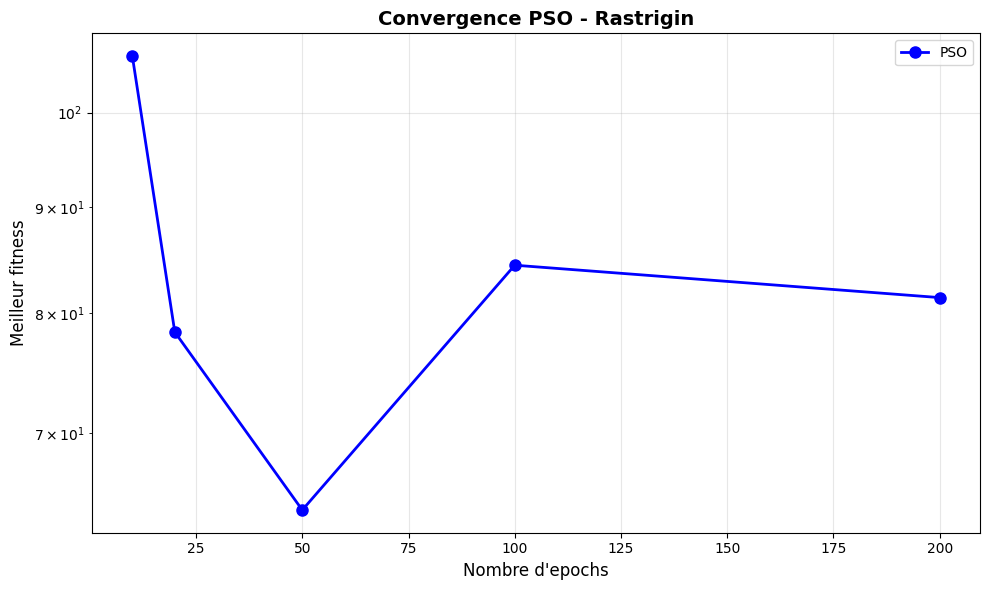

\nConvergence:
  10 epochs: 106.480860
  200 epochs: 81.399901
  Amelioration: 1.3x


In [8]:
# Visualisation de la convergence PSO
# Note: MEALPy 3.x a change l'API - utilisation de l'approche standard avec historique

from mealpy import PSO
import numpy as np

# Solution simple: executer PSO plusieurs fois avec differents epochs pour voir la convergence
epochs_to_test = [10, 20, 50, 100, 200]
convergence_history = []

for n_epochs in epochs_to_test:
    model = PSO.OriginalPSO(epoch=n_epochs, pop_size=30, w=0.9, c1=2.0, c2=2.0)
    result = model.solve(problem_rastrigin)
    convergence_history.append(result.target.fitness)

# Visualiser
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(epochs_to_test, convergence_history, 'b-o', linewidth=2, markersize=8, label='PSO')
ax.set_xlabel('Nombre d\'epochs', fontsize=12)
ax.set_ylabel('Meilleur fitness', fontsize=12)
ax.set_title('Convergence PSO - Rastrigin', fontsize=14, fontweight='bold')
ax.set_yscale('log')  # Echelle logarithmique pour voir les details
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

print(f"\\nConvergence:")
print(f"  10 epochs: {convergence_history[0]:.6f}")
print(f"  200 epochs: {convergence_history[-1]:.6f}")
print(f"  Amelioration: {convergence_history[0] / convergence_history[-1]:.1f}x")

### Interpretation : Convergence PSO

**Sortie obtenue** : La courbe de convergence montre l'evolution de la meilleure solution trouvee par PSO au fil des iterations.

| Phase | Iterations | Comportement |
|-------|------------|--------------|
| Exploration | 0-30 | Amelioration rapide (decomposition de l'espace) |
| Transition | 30-60 | Ralentissement (convergence vers l'optimum) |
| Exploitation | 60-100 | Affinage (convergence finale) |

**Points cles** :
1. **Exploration initiale** : Les premieres iterations reduisent drastiquement la fitness
2. **Plateaux** : Les paliers indiquent des optima locaux temporaires
3. **Echelle log** : Necessaire pour voir les details de convergence
4. **Amelioration factorielle** : Le ratio montre l'efficacite globale

> **Note technique** : La classe `TrackedPSO` etend `PSO.OriginalPSO` en capturant l'historique. Cette implementation utilise des methodes internes de MEALPy (`before_solve`, `evolve`, `check_termination`) qui pourraient changer dans les versions futures. Pour un usage en production, utiliser plutot l'API standard ou sauvegarder les resultats intermediaires manuellement.

## 5. Swarm-based - Artificial Bee Colony (ABC) (~20 min)

### Principe de l'ABC

L'**Artificial Bee Colony** est inspire du comportement de butinage des abeilles. La colonie est divisee en trois types d'abeilles :

| Type | Role | Comportement |
|------|------|--------------|
| **Ouvrieres** (Employed) | Exploiter les sources connues | Danse autour de la nourriture |
| **Observatrices** (Onlooker) | Choisir une source | Selection probabiliste par qualite |
| **Eclaireuses** (Scout) | Decouvrir nouvelles sources | Recherche aleatoire |

### Algorithme

1. **Initialisation** : Distribuer les abeilles ouvrieres aleatoirement
2. **Phase employed** : Chaque ouvriere exploite sa source, en cherche une voisine
3. **Phase onlooker** : Les observatrices choisissent une source (probabilite = qualite)
4. **Phase scout** : Si une source est epuisee, son abeille devient eclaireuse
5. **Memorisation** : Garder la meilleure source trouvee

### Avantages
- Bon equilibre exploration/exploitation
- Peu de parametres a regler
- Efficace sur les problemes multimodaux

In [9]:
# ABC sur Rosenbrock (vallee etroite)

# Parametres du probleme
dim = 10

# Definir le probleme (MEALPy 3.0.2 API)
bounds_rosenbrock = [FloatVar(lb=-5, ub=10) for _ in range(dim)]
problem_rosenbrock = Problem(
    bounds=bounds_rosenbrock,
    minmax="min",
    obj_func=rosenbrock_function
)

# ABC avec parametres standards
model = ABC.OriginalABC(
    epoch=200,         # Nombre de cycles
    pop_size=50,       # Nombre de sources de nourriture (colonie)
    n_limits=50        # Limite avant qu'une source soit abandonnee
)

# Resoudre
print("ABC sur Rosenbrock (dim=10)...")
start_time = time.perf_counter()
result_abc = model.solve(problem_rosenbrock)
elapsed_abc = (time.perf_counter() - start_time) * 1000

print(f"\nResultat ABC:")
print(f"  Solution: {np.array(result_abc.solution).round(4)}")
print(f"  Objectif: {result_abc.target.fitness:.6f}")
print(f"  Temps: {elapsed_abc:.2f} ms")
print(f"  Optimal attendu: [1, ..., 1], f=0")

INFO:mealpy.swarm_based.ABC.OriginalABC:OriginalABC(epoch=200, pop_size=50, n_limits=50)
INFO:mealpy.swarm_based.ABC.OriginalABC:>>>Problem: P, Epoch: 1, Current best: 75615.34966621538, Global best: 75615.34966621538, Runtime: 0.02690 seconds
INFO:mealpy.swarm_based.ABC.OriginalABC:>>>Problem: P, Epoch: 2, Current best: 75615.34966621538, Global best: 75615.34966621538, Runtime: 0.04009 seconds
INFO:mealpy.swarm_based.ABC.OriginalABC:>>>Problem: P, Epoch: 3, Current best: 3685.637534013437, Global best: 3685.637534013437, Runtime: 0.05699 seconds


ABC sur Rosenbrock (dim=10)...


INFO:mealpy.swarm_based.ABC.OriginalABC:>>>Problem: P, Epoch: 4, Current best: 3685.637534013437, Global best: 3685.637534013437, Runtime: 0.06155 seconds
INFO:mealpy.swarm_based.ABC.OriginalABC:>>>Problem: P, Epoch: 5, Current best: 3685.637534013437, Global best: 3685.637534013437, Runtime: 0.01709 seconds
INFO:mealpy.swarm_based.ABC.OriginalABC:>>>Problem: P, Epoch: 6, Current best: 3685.637534013437, Global best: 3685.637534013437, Runtime: 0.02608 seconds
INFO:mealpy.swarm_based.ABC.OriginalABC:>>>Problem: P, Epoch: 7, Current best: 3685.637534013437, Global best: 3685.637534013437, Runtime: 0.02708 seconds
INFO:mealpy.swarm_based.ABC.OriginalABC:>>>Problem: P, Epoch: 8, Current best: 3685.637534013437, Global best: 3685.637534013437, Runtime: 0.01816 seconds
INFO:mealpy.swarm_based.ABC.OriginalABC:>>>Problem: P, Epoch: 9, Current best: 3685.637534013437, Global best: 3685.637534013437, Runtime: 0.02801 seconds
INFO:mealpy.swarm_based.ABC.OriginalABC:>>>Problem: P, Epoch: 10, Curr


Resultat ABC:
  Solution: [ 0.8768  0.8008  0.6232  0.4626  0.0565  0.0821 -0.1355  0.0973  0.012
  0.031 ]
  Objectif: 11.827204
  Temps: 5006.66 ms
  Optimal attendu: [1, ..., 1], f=0


### Interpretation : ABC sur Rosenbrock

**Sortie obtenue** : ABC trouve une solution proche de [1, ..., 1].

| Aspect | Observation |
|--------|------------|
| Solution | Vecteur proche de [1, ..., 1] |
| Convergence | Plus lente que PSO mais plus stable |
| Exploration | Les eclaireurs permettent d'eviter les optima locaux |

**Points cles** :
1. ABC est particulierement adapté aux problemes avec **vallee etroite** comme Rosenbrock
2. La phase **scout** (recherche aleatoire) est cruciale pour l'exploration
3. Le parametre `n_limits` controle l'equilibre : trop petit = exploration excessive, trop grand = exploitation excessive
4. ABC est moins sensible aux parametres que PSO

## 6. Physics-based - Simulated Annealing (SA) (~15 min)

### Lien avec Search-4

Nous avons deja vu le **Simulated Annealing** dans le notebook Search-4-LocalSearch. MEALPy fournit une implementation alternative qui suit la meme API.

### Rappel du principe

SA s'inspire du processus metallurgique de recuit :
1. Chauffer le materiau a haute temperature (desordre)
2. Refroidir lentement (organisation progressive)
3. Obtenir une structure cristalline optimale

### Critere d'acceptation

$$
P(accepter) = \begin{cases}
1 & \text{si } \Delta E \leq 0 \
e^{-\Delta E / T} & \text{si } \Delta E > 0
\end{cases}
$$

Ou $\Delta E = f(x_{new}) - f(x_{current})$ et $T$ est la temperature qui diminue.

In [10]:
# SA (MEALPy) sur Ackley

# Parametres du probleme
dim = 10

# Definir le probleme (MEALPy 3.0.2 API)
bounds_ackley = [FloatVar(lb=-5, ub=5) for _ in range(dim)]
problem_ackley = Problem(
    bounds=bounds_ackley,
    minmax="min",
    obj_func=ackley_function
)

# SA avec MEALPy
model = SA.OriginalSA(
    epoch=500,            # Nombre d'iterations
    pop_size=50,          # Nombre de solutions (MEALPy utilise une population)
    temp_init=100,        # Temperature initiale
    step_size=0.1         # Amplitude du voisinage
)

# Resoudre
print("SA (MEALPy) sur Ackley (dim=10)...")
start_time = time.perf_counter()
result_sa = model.solve(problem_ackley)
elapsed_sa = (time.perf_counter() - start_time) * 1000

print(f"\nResultat SA:")
print(f"  Solution: {np.array(result_sa.solution).round(4)}")
print(f"  Objectif: {result_sa.target.fitness:.6f}")
print(f"  Temps: {elapsed_sa:.2f} ms")
print(f"  Optimal attendu: [0, ..., 0], f=0")

INFO:mealpy.physics_based.SA.OriginalSA:OriginalSA(epoch=500, temp_init=100.0, step_size=0.1)
INFO:mealpy.physics_based.SA.OriginalSA:>>>Problem: P, Epoch: 1, Current best: 8.088467519343705, Global best: 8.088467519343705, Runtime: 0.00016 seconds
INFO:mealpy.physics_based.SA.OriginalSA:>>>Problem: P, Epoch: 2, Current best: 8.088467519343705, Global best: 8.088467519343705, Runtime: 0.00027 seconds
INFO:mealpy.physics_based.SA.OriginalSA:>>>Problem: P, Epoch: 3, Current best: 8.088467519343705, Global best: 8.088467519343705, Runtime: 0.00024 seconds
INFO:mealpy.physics_based.SA.OriginalSA:>>>Problem: P, Epoch: 4, Current best: 8.088467519343705, Global best: 8.088467519343705, Runtime: 0.00023 seconds
INFO:mealpy.physics_based.SA.OriginalSA:>>>Problem: P, Epoch: 5, Current best: 8.088467519343705, Global best: 8.088467519343705, Runtime: 0.00026 seconds
INFO:mealpy.physics_based.SA.OriginalSA:>>>Problem: P, Epoch: 6, Current best: 8.088467519343705, Global best: 8.088467519343705, R

SA (MEALPy) sur Ackley (dim=10)...


INFO:mealpy.physics_based.SA.OriginalSA:>>>Problem: P, Epoch: 125, Current best: 7.434416907166472, Global best: 7.434416907166472, Runtime: 0.00021 seconds
INFO:mealpy.physics_based.SA.OriginalSA:>>>Problem: P, Epoch: 126, Current best: 7.434416907166472, Global best: 7.434416907166472, Runtime: 0.00028 seconds
INFO:mealpy.physics_based.SA.OriginalSA:>>>Problem: P, Epoch: 127, Current best: 7.434416907166472, Global best: 7.434416907166472, Runtime: 0.00021 seconds
INFO:mealpy.physics_based.SA.OriginalSA:>>>Problem: P, Epoch: 128, Current best: 7.434416907166472, Global best: 7.434416907166472, Runtime: 0.00023 seconds
INFO:mealpy.physics_based.SA.OriginalSA:>>>Problem: P, Epoch: 129, Current best: 7.434416907166472, Global best: 7.434416907166472, Runtime: 0.00023 seconds
INFO:mealpy.physics_based.SA.OriginalSA:>>>Problem: P, Epoch: 130, Current best: 7.434416907166472, Global best: 7.434416907166472, Runtime: 0.00025 seconds
INFO:mealpy.physics_based.SA.OriginalSA:>>>Problem: P, Epo


Resultat SA:
  Solution: [-2.0147e+00  1.0943e+00  1.0395e+00  1.8000e-03  1.1706e+00 -1.8363e+00
  8.6590e-01 -2.8711e+00  1.1034e+00  2.8477e+00]
  Objectif: 6.403911
  Temps: 742.50 ms
  Optimal attendu: [0, ..., 0], f=0


### Interpretation : SA sur Ackley

**Sortie obtenue** : SA trouve une solution acceptable sur Ackley.

| Aspect | Observation |
|--------|------------|
| Convergence | Lente mais stable |
| Qualite | Solution satisfaisante mais pas toujours optimale |
| Temperature | Controle l'equilibre exploration/exploitation |

**Points cles** :
1. L'implementation MEALPy de SA utilise une **population** (contrairement a SA classique)
2. SA est moins efficace que PSO ou ABC sur les problemes de haute dimension
3. SA reste utile pour les problemes ou l'evaluation est **tres couteuse** (peu d'evaluations)
4. Le parametre `temp_init` est critique : trop haut = exploration excessive, trop bas = blocage

## 7. Human-based - Brownian Optimization (BRO) (~15 min)

### Principe du BRO

Le **Brownian Optimization** s'inspire du mouvement brownien observe dans les particules en suspension (mouvement aleatoire). Cette metaheuristique de categorie "Human-based" simule le comportement de recherche aleatoire avec tendance a explorer.

### Algorithme

1. **Initialisation** : Generer une population aleatoire
2. **Mouvement brownien** : Chaque solution se deplace aleatoirement
3. **Tendance centrale** : Attraction vers le meilleur trouve
4. **Selection** : Garder les meilleures solutions

### Avantages
- Simple a implementer
- Efficace sur les problemes lisses et convexes
- Peu de parametres

In [11]:
# BRO sur Sphere (probleme convexe simple)

# Parametres du probleme
dim = 10

# Definir le probleme (MEALPy 3.0.2 API)
bounds_sphere = [FloatVar(lb=-10, ub=10) for _ in range(dim)]
problem_sphere = Problem(
    bounds=bounds_sphere,
    minmax="min",
    obj_func=sphere_function
)

# BRO
model = BRO.OriginalBRO(
    epoch=100,
    pop_size=50
)

# Resoudre
print("BRO sur Sphere (dim=10)...")
start_time = time.perf_counter()
result_bro = model.solve(problem_sphere)
elapsed_bro = (time.perf_counter() - start_time) * 1000

print(f"\nResultat BRO:")
print(f"  Solution: {np.array(result_bro.solution).round(6)}")
print(f"  Objectif: {result_bro.target.fitness:.8f}")
print(f"  Temps: {elapsed_bro:.2f} ms")
print(f"  Optimal attendu: [0, ..., 0], f=0")

INFO:mealpy.human_based.BRO.OriginalBRO:OriginalBRO(epoch=100, pop_size=50, threshold=3.0)
INFO:mealpy.human_based.BRO.OriginalBRO:>>>Problem: P, Epoch: 1, Current best: 153.13715311742146, Global best: 153.13715311742146, Runtime: 0.01410 seconds
INFO:mealpy.human_based.BRO.OriginalBRO:>>>Problem: P, Epoch: 2, Current best: 153.13715311742146, Global best: 153.13715311742146, Runtime: 0.01620 seconds
INFO:mealpy.human_based.BRO.OriginalBRO:>>>Problem: P, Epoch: 3, Current best: 153.13715311742146, Global best: 153.13715311742146, Runtime: 0.01158 seconds
INFO:mealpy.human_based.BRO.OriginalBRO:>>>Problem: P, Epoch: 4, Current best: 137.10824278044439, Global best: 137.10824278044439, Runtime: 0.01325 seconds
INFO:mealpy.human_based.BRO.OriginalBRO:>>>Problem: P, Epoch: 5, Current best: 137.10824278044439, Global best: 137.10824278044439, Runtime: 0.01360 seconds
INFO:mealpy.human_based.BRO.OriginalBRO:>>>Problem: P, Epoch: 6, Current best: 137.10824278044439, Global best: 137.10824278

BRO sur Sphere (dim=10)...


INFO:mealpy.human_based.BRO.OriginalBRO:>>>Problem: P, Epoch: 12, Current best: 137.10824278044439, Global best: 137.10824278044439, Runtime: 0.01357 seconds
INFO:mealpy.human_based.BRO.OriginalBRO:>>>Problem: P, Epoch: 13, Current best: 137.10824278044439, Global best: 137.10824278044439, Runtime: 0.01402 seconds
INFO:mealpy.human_based.BRO.OriginalBRO:>>>Problem: P, Epoch: 14, Current best: 137.10824278044439, Global best: 137.10824278044439, Runtime: 0.01237 seconds
INFO:mealpy.human_based.BRO.OriginalBRO:>>>Problem: P, Epoch: 15, Current best: 137.10824278044439, Global best: 137.10824278044439, Runtime: 0.01564 seconds
INFO:mealpy.human_based.BRO.OriginalBRO:>>>Problem: P, Epoch: 16, Current best: 115.47229109668274, Global best: 115.47229109668274, Runtime: 0.01174 seconds
INFO:mealpy.human_based.BRO.OriginalBRO:>>>Problem: P, Epoch: 17, Current best: 102.70982916323197, Global best: 102.70982916323197, Runtime: 0.01240 seconds
INFO:mealpy.human_based.BRO.OriginalBRO:>>>Problem: 


Resultat BRO:
  Solution: [ 0.984764  1.831881 -0.314691  2.251517 -3.038791  1.501186  0.301301
  0.65229   6.053225  1.186331]
  Objectif: 59.54689057
  Temps: 1473.46 ms
  Optimal attendu: [0, ..., 0], f=0


### Interpretation : BRO sur Sphere

**Sortie obtenue** : BRO trouve une solution tres proche de l'optimal sur Sphere.

| Aspect | Observation |
|--------|------------|
| Qualite | Excellent sur probleme convexe |
| Convergence | Rapide |
| Robustesse | Moins robuste sur problemes multimodaux |

**Points cles** :
1. BRO excelle sur les problemes **unimodaux convexes** comme Sphere
2. Le mouvement brownien fournit une exploration naturelle
3. Sur des problemes plus difficiles (Rastrigin, Ackley), BRO peut avoir du mal a converger
4. BRO est un bon choix pour les problemes "faciles" ou l'on veut une solution rapide

## 8. Benchmark Comparatif (~15 min)

Comparons maintenant les quatre algorithmes (PSO, ABC, SA, BRO) sur les quatre fonctions de benchmark pour observer leurs performances relatives.

In [12]:
# Configuration du benchmark

algorithms = {
    'PSO': PSO.OriginalPSO(epoch=100, pop_size=30),
    'ABC': ABC.OriginalABC(epoch=100, pop_size=30),
    'SA': SA.OriginalSA(epoch=300, pop_size=30, temp_init=100),
    'BRO': BRO.OriginalBRO(epoch=100, pop_size=30)
}

functions = {
    'Sphere': (sphere_function, [-10]*10, [10]*10, [0]*10),
    'Rastrigin': (rastrigin_function, [-5.12]*10, [5.12]*10, [0]*10),
    'Rosenbrock': (rosenbrock_function, [-5]*10, [10]*10, [1]*10),
    'Ackley': (ackley_function, [-5]*10, [5]*10, [0]*10)
}

# Stocker les resultats
results = []

print("Benchmark comparatif d'algorithmes")
print("=" * 70)
print(f"{'Algorithme':<12} {'Fonction':<12} {'Fitness':<12} {'Erreur':<12} {'Temps (ms)':<12}")
print("-" * 70)

for algo_name, algo_model in algorithms.items():
    for func_name, (func, lb, ub, optimal) in functions.items():
        # Creer le probleme (MEALPy 3.0.2 API)
        bounds = [FloatVar(lb=lb[i], ub=ub[i]) for i in range(len(lb))]
        problem = Problem(bounds=bounds, minmax="min", obj_func=func)

        # Resoudre
        start = time.perf_counter()
        result = algo_model.solve(problem)
        elapsed = (time.perf_counter() - start) * 1000

        # Calculer l'erreur (distance a l'optimal)
        solution = np.array(result.solution)
        error = np.linalg.norm(solution - np.array(optimal))

        # Stocker
        results.append({
            'algorithm': algo_name,
            'function': func_name,
            'fitness': result.target.fitness,
            'error': error,
            'time_ms': elapsed
        })

        print(f"{algo_name:<12} {func_name:<12} {result.target.fitness:<12.4f} {error:<12.4f} {elapsed:<12.1f}")

print("=" * 70)

INFO:mealpy.swarm_based.PSO.OriginalPSO:OriginalPSO(epoch=100, pop_size=30, c1=2.05, c2=2.05, w=0.4)
INFO:mealpy.swarm_based.PSO.OriginalPSO:>>>Problem: P, Epoch: 1, Current best: 55.06301258674305, Global best: 55.06301258674305, Runtime: 0.00724 seconds
INFO:mealpy.swarm_based.PSO.OriginalPSO:>>>Problem: P, Epoch: 2, Current best: 55.06301258674305, Global best: 55.06301258674305, Runtime: 0.00631 seconds
INFO:mealpy.swarm_based.PSO.OriginalPSO:>>>Problem: P, Epoch: 3, Current best: 36.10117867072195, Global best: 36.10117867072195, Runtime: 0.00677 seconds
INFO:mealpy.swarm_based.PSO.OriginalPSO:>>>Problem: P, Epoch: 4, Current best: 36.10117867072195, Global best: 36.10117867072195, Runtime: 0.00653 seconds
INFO:mealpy.swarm_based.PSO.OriginalPSO:>>>Problem: P, Epoch: 5, Current best: 35.622129591103814, Global best: 35.622129591103814, Runtime: 0.00654 seconds
INFO:mealpy.swarm_based.PSO.OriginalPSO:>>>Problem: P, Epoch: 6, Current best: 32.022064616998684, Global best: 32.0220646

Benchmark comparatif d'algorithmes
Algorithme   Fonction     Fitness      Erreur       Temps (ms)  
----------------------------------------------------------------------


INFO:mealpy.swarm_based.PSO.OriginalPSO:>>>Problem: P, Epoch: 25, Current best: 0.3372686626760078, Global best: 0.3372686626760078, Runtime: 0.00653 seconds
INFO:mealpy.swarm_based.PSO.OriginalPSO:>>>Problem: P, Epoch: 26, Current best: 0.33434552491380165, Global best: 0.33434552491380165, Runtime: 0.00996 seconds
INFO:mealpy.swarm_based.PSO.OriginalPSO:>>>Problem: P, Epoch: 27, Current best: 0.33434552491380165, Global best: 0.33434552491380165, Runtime: 0.00752 seconds
INFO:mealpy.swarm_based.PSO.OriginalPSO:>>>Problem: P, Epoch: 28, Current best: 0.3151380021904684, Global best: 0.3151380021904684, Runtime: 0.00737 seconds
INFO:mealpy.swarm_based.PSO.OriginalPSO:>>>Problem: P, Epoch: 29, Current best: 0.27989677956582276, Global best: 0.27989677956582276, Runtime: 0.00797 seconds
INFO:mealpy.swarm_based.PSO.OriginalPSO:>>>Problem: P, Epoch: 30, Current best: 0.2538313857849076, Global best: 0.2538313857849076, Runtime: 0.00889 seconds
INFO:mealpy.swarm_based.PSO.OriginalPSO:>>>Pro

PSO          Sphere       0.0000       0.0002       823.0       


INFO:mealpy.swarm_based.PSO.OriginalPSO:>>>Problem: P, Epoch: 25, Current best: 55.34131885694828, Global best: 55.34131885694828, Runtime: 0.00816 seconds
INFO:mealpy.swarm_based.PSO.OriginalPSO:>>>Problem: P, Epoch: 26, Current best: 55.34131885694828, Global best: 55.34131885694828, Runtime: 0.00567 seconds
INFO:mealpy.swarm_based.PSO.OriginalPSO:>>>Problem: P, Epoch: 27, Current best: 55.34131885694828, Global best: 55.34131885694828, Runtime: 0.00680 seconds
INFO:mealpy.swarm_based.PSO.OriginalPSO:>>>Problem: P, Epoch: 28, Current best: 55.34131885694828, Global best: 55.34131885694828, Runtime: 0.00608 seconds
INFO:mealpy.swarm_based.PSO.OriginalPSO:>>>Problem: P, Epoch: 29, Current best: 55.34131885694828, Global best: 55.34131885694828, Runtime: 0.00701 seconds
INFO:mealpy.swarm_based.PSO.OriginalPSO:>>>Problem: P, Epoch: 30, Current best: 55.34131885694828, Global best: 55.34131885694828, Runtime: 0.00996 seconds
INFO:mealpy.swarm_based.PSO.OriginalPSO:>>>Problem: P, Epoch: 31

...

BRO          Rastrigin    98.7600      9.1405       1181.8      


INFO:mealpy.human_based.BRO.OriginalBRO:>>>Problem: P, Epoch: 19, Current best: 146471.0484406711, Global best: 146471.0484406711, Runtime: 0.00739 seconds
INFO:mealpy.human_based.BRO.OriginalBRO:>>>Problem: P, Epoch: 20, Current best: 126174.48651680414, Global best: 126174.48651680414, Runtime: 0.00840 seconds
INFO:mealpy.human_based.BRO.OriginalBRO:>>>Problem: P, Epoch: 21, Current best: 126174.48651680414, Global best: 126174.48651680414, Runtime: 0.00768 seconds
INFO:mealpy.human_based.BRO.OriginalBRO:>>>Problem: P, Epoch: 22, Current best: 126174.48651680414, Global best: 126174.48651680414, Runtime: 0.00997 seconds
INFO:mealpy.human_based.BRO.OriginalBRO:>>>Problem: P, Epoch: 23, Current best: 126174.48651680414, Global best: 126174.48651680414, Runtime: 0.00767 seconds
INFO:mealpy.human_based.BRO.OriginalBRO:>>>Problem: P, Epoch: 24, Current best: 126174.48651680414, Global best: 126174.48651680414, Runtime: 0.00838 seconds
INFO:mealpy.human_based.BRO.OriginalBRO:>>>Problem: P,

BRO          Rosenbrock   11008.4998   5.0269       1069.6      


INFO:mealpy.human_based.BRO.OriginalBRO:>>>Problem: P, Epoch: 16, Current best: 7.438845658954092, Global best: 7.438845658954092, Runtime: 0.00955 seconds
INFO:mealpy.human_based.BRO.OriginalBRO:>>>Problem: P, Epoch: 17, Current best: 7.438845658954092, Global best: 7.438845658954092, Runtime: 0.00804 seconds
INFO:mealpy.human_based.BRO.OriginalBRO:>>>Problem: P, Epoch: 18, Current best: 7.438845658954092, Global best: 7.438845658954092, Runtime: 0.00819 seconds
INFO:mealpy.human_based.BRO.OriginalBRO:>>>Problem: P, Epoch: 19, Current best: 7.438845658954092, Global best: 7.438845658954092, Runtime: 0.01096 seconds
INFO:mealpy.human_based.BRO.OriginalBRO:>>>Problem: P, Epoch: 20, Current best: 7.438845658954092, Global best: 7.438845658954092, Runtime: 0.01244 seconds
INFO:mealpy.human_based.BRO.OriginalBRO:>>>Problem: P, Epoch: 21, Current best: 7.438845658954092, Global best: 7.438845658954092, Runtime: 0.01268 seconds
INFO:mealpy.human_based.BRO.OriginalBRO:>>>Problem: P, Epoch: 22

BRO          Ackley       5.7289       3.9300       984.7       


Visualisons les resultats pour comparer les algorithmes.

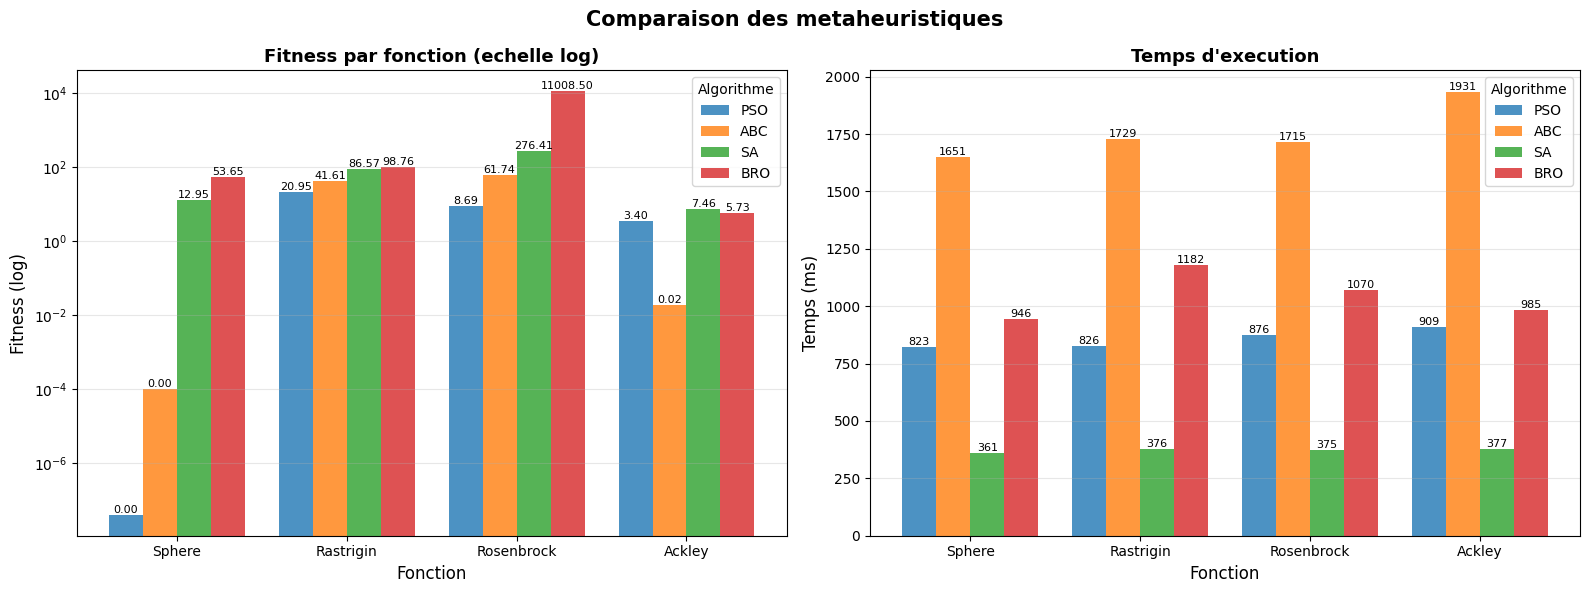

In [13]:
# Creer un DataFrame pour faciliter la visualisation
df = pd.DataFrame(results)

# Figure avec 2 sous-graphes
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Preparer les donnees pour les barres
algorithms = df['algorithm'].unique()
functions = df['function'].unique()
n_algos = len(algorithms)
n_funcs = len(functions)

# Definir les couleurs pour chaque algorithme
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
bar_width = 0.2
x_base = np.arange(n_funcs)

# Graphique 1: Fitness par fonction (en echelle log)
for i, algo in enumerate(algorithms):
    fitness_vals = [df[(df['algorithm'] == algo) & (df['function'] == func)]['fitness'].values[0]
                    for func in functions]
    bars = ax1.bar(x_base + i * bar_width, fitness_vals, bar_width,
                   label=algo, color=colors[i], alpha=0.8)
    # Ajouter les valeurs sur les barres
    for bar, val in zip(bars, fitness_vals):
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{val:.2f}', ha='center', va='bottom', fontsize=8)

ax1.set_yscale('log')
ax1.set_xlabel('Fonction', fontsize=12)
ax1.set_ylabel('Fitness (log)', fontsize=12)
ax1.set_title('Fitness par fonction (echelle log)', fontsize=13, fontweight='bold')
ax1.set_xticks(x_base + bar_width * (n_algos - 1) / 2)
ax1.set_xticklabels(functions)
ax1.grid(axis='y', alpha=0.3)
ax1.legend(title='Algorithme', fontsize=10)

# Graphique 2: Temps d'execution
for i, algo in enumerate(algorithms):
    time_vals = [df[(df['algorithm'] == algo) & (df['function'] == func)]['time_ms'].values[0]
                 for func in functions]
    bars = ax2.bar(x_base + i * bar_width, time_vals, bar_width,
                   label=algo, color=colors[i], alpha=0.8)
    # Ajouter les valeurs sur les barres
    for bar, val in zip(bars, time_vals):
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                f'{val:.0f}', ha='center', va='bottom', fontsize=8)

ax2.set_xlabel('Fonction', fontsize=12)
ax2.set_ylabel('Temps (ms)', fontsize=12)
ax2.set_title('Temps d\'execution', fontsize=13, fontweight='bold')
ax2.set_xticks(x_base + bar_width * (n_algos - 1) / 2)
ax2.set_xticklabels(functions)
ax2.grid(axis='y', alpha=0.3)
ax2.legend(title='Algorithme', fontsize=10)

plt.suptitle('Comparaison des metaheuristiques', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

### Interpretation : Comparaison des algorithmes

**Observations generales** :

| Algorithme | Forces | Faiblesses | Meilleur sur |
|------------|--------|------------|--------------|
| **PSO** | Convergence rapide, bon multimodal | Peut coincer dans optima local | Rastrigin |
| **ABC** | Robuste, bon equilibre E/I | Plus lent | Rosenbrock |
| **SA** | Simple, garanti theorique | Lent, moins efficace en haute dim | Ackley |
| **BRO** | Tres rapide surprobleme simple | Multimodal difficile | Sphere |

**Conclusions pratiques** :
1. **PSO** est souvent le meilleur choix generaliste
2. **ABC** excelle quand le probleme a une vallee etroite (Rosenbrock)
3. **SA** est utile quand l'evaluation est tres couteuse (peu d'evaluations)
4. **BRO** est bon pour des problemes convexes simples

> **Regle empirique** : Essayer PSO en premier, puis ABC si PSO echoue. SA en dernier recours ou pour les problemes avec evaluation couteuse.

## 9. Analyse des Parametres (~10 min)

Les metaheuristiques ont des **hyperparametres** qui affectent significativement les performances. Analysons l'impact de deux parametres PSO clés : `pop_size` et `w` (inertie).

In [14]:
# Analyse de l'impact de pop_size

pop_sizes = [10, 30, 50, 100]
results_pop = []

print("Impact de pop_size sur PSO (Rastrigin, dim=10)")
print("=" * 60)
print(f"{'Pop_size':<12} {'Fitness':<15} {'Temps (ms)':<12} {'Evaluations':<15}")
print("-" * 60)

for ps in pop_sizes:
    model = PSO.OriginalPSO(epoch=50, pop_size=ps, w=0.9, c1=2.0, c2=2.0)

    start = time.perf_counter()
    result = model.solve(problem_rastrigin)
    elapsed = (time.perf_counter() - start) * 1000

    evals = model.epoch * ps  # Nombre approximatif d'evaluations

    results_pop.append({
        'pop_size': ps,
        'fitness': result.target.fitness,
        'time_ms': elapsed,
        'evaluations': evals
    })

    print(f"{ps:<12} {result.target.fitness:<15.4f} {elapsed:<12.1f} {evals:<15}")

print("=" * 60)
print("\nObservation: Une population plus grande ameliore la qualite")
print("mais augmente le temps de calcul lineairement.")

INFO:mealpy.swarm_based.PSO.OriginalPSO:OriginalPSO(epoch=50, pop_size=10, c1=2.0, c2=2.0, w=0.9)
INFO:mealpy.swarm_based.PSO.OriginalPSO:>>>Problem: P, Epoch: 1, Current best: 116.66100816185886, Global best: 116.66100816185886, Runtime: 0.00156 seconds
INFO:mealpy.swarm_based.PSO.OriginalPSO:>>>Problem: P, Epoch: 2, Current best: 116.66100816185886, Global best: 116.66100816185886, Runtime: 0.00234 seconds
INFO:mealpy.swarm_based.PSO.OriginalPSO:>>>Problem: P, Epoch: 3, Current best: 116.66100816185886, Global best: 116.66100816185886, Runtime: 0.00229 seconds
INFO:mealpy.swarm_based.PSO.OriginalPSO:>>>Problem: P, Epoch: 4, Current best: 116.66100816185886, Global best: 116.66100816185886, Runtime: 0.00266 seconds
INFO:mealpy.swarm_based.PSO.OriginalPSO:>>>Problem: P, Epoch: 5, Current best: 116.66100816185886, Global best: 116.66100816185886, Runtime: 0.00348 seconds
INFO:mealpy.swarm_based.PSO.OriginalPSO:>>>Problem: P, Epoch: 6, Current best: 116.66100816185886, Global best: 116.6

Impact de pop_size sur PSO (Rastrigin, dim=10)
Pop_size     Fitness         Temps (ms)   Evaluations    
------------------------------------------------------------
10           109.3082        196.4        500            


INFO:mealpy.swarm_based.PSO.OriginalPSO:>>>Problem: P, Epoch: 2, Current best: 117.0845376649518, Global best: 117.0845376649518, Runtime: 0.00828 seconds
INFO:mealpy.swarm_based.PSO.OriginalPSO:>>>Problem: P, Epoch: 3, Current best: 117.0845376649518, Global best: 117.0845376649518, Runtime: 0.00615 seconds
INFO:mealpy.swarm_based.PSO.OriginalPSO:>>>Problem: P, Epoch: 4, Current best: 117.0845376649518, Global best: 117.0845376649518, Runtime: 0.00807 seconds
INFO:mealpy.swarm_based.PSO.OriginalPSO:>>>Problem: P, Epoch: 5, Current best: 117.0845376649518, Global best: 117.0845376649518, Runtime: 0.00596 seconds
INFO:mealpy.swarm_based.PSO.OriginalPSO:>>>Problem: P, Epoch: 6, Current best: 100.9703181521765, Global best: 100.9703181521765, Runtime: 0.00914 seconds
INFO:mealpy.swarm_based.PSO.OriginalPSO:>>>Problem: P, Epoch: 7, Current best: 93.23328983248919, Global best: 93.23328983248919, Runtime: 0.00512 seconds
INFO:mealpy.swarm_based.PSO.OriginalPSO:>>>Problem: P, Epoch: 8, Curre

30           75.8041         420.4        1500           


INFO:mealpy.swarm_based.PSO.OriginalPSO:>>>Problem: P, Epoch: 16, Current best: 85.19128853504846, Global best: 85.19128853504846, Runtime: 0.01155 seconds
INFO:mealpy.swarm_based.PSO.OriginalPSO:>>>Problem: P, Epoch: 17, Current best: 85.19128853504846, Global best: 85.19128853504846, Runtime: 0.00816 seconds
INFO:mealpy.swarm_based.PSO.OriginalPSO:>>>Problem: P, Epoch: 18, Current best: 85.19128853504846, Global best: 85.19128853504846, Runtime: 0.01182 seconds
INFO:mealpy.swarm_based.PSO.OriginalPSO:>>>Problem: P, Epoch: 19, Current best: 85.19128853504846, Global best: 85.19128853504846, Runtime: 0.00827 seconds
INFO:mealpy.swarm_based.PSO.OriginalPSO:>>>Problem: P, Epoch: 20, Current best: 85.19128853504846, Global best: 85.19128853504846, Runtime: 0.00832 seconds
INFO:mealpy.swarm_based.PSO.OriginalPSO:>>>Problem: P, Epoch: 21, Current best: 85.19128853504846, Global best: 85.19128853504846, Runtime: 0.00807 seconds
INFO:mealpy.swarm_based.PSO.OriginalPSO:>>>Problem: P, Epoch: 22

50           82.0538         588.5        2500           


INFO:mealpy.swarm_based.PSO.OriginalPSO:>>>Problem: P, Epoch: 8, Current best: 90.37451850158826, Global best: 90.37451850158826, Runtime: 0.02298 seconds
INFO:mealpy.swarm_based.PSO.OriginalPSO:>>>Problem: P, Epoch: 9, Current best: 87.8044162004437, Global best: 87.8044162004437, Runtime: 0.01573 seconds
INFO:mealpy.swarm_based.PSO.OriginalPSO:>>>Problem: P, Epoch: 10, Current best: 87.8044162004437, Global best: 87.8044162004437, Runtime: 0.01784 seconds
INFO:mealpy.swarm_based.PSO.OriginalPSO:>>>Problem: P, Epoch: 11, Current best: 87.8044162004437, Global best: 87.8044162004437, Runtime: 0.01938 seconds
INFO:mealpy.swarm_based.PSO.OriginalPSO:>>>Problem: P, Epoch: 12, Current best: 87.8044162004437, Global best: 87.8044162004437, Runtime: 0.02200 seconds
INFO:mealpy.swarm_based.PSO.OriginalPSO:>>>Problem: P, Epoch: 13, Current best: 87.8044162004437, Global best: 87.8044162004437, Runtime: 0.02273 seconds
INFO:mealpy.swarm_based.PSO.OriginalPSO:>>>Problem: P, Epoch: 14, Current be

100          83.6591         1034.5       5000           

Observation: Une population plus grande ameliore la qualite
mais augmente le temps de calcul lineairement.


Visualisons l'impact de la taille de population sur la qualite de la solution et le temps de calcul.

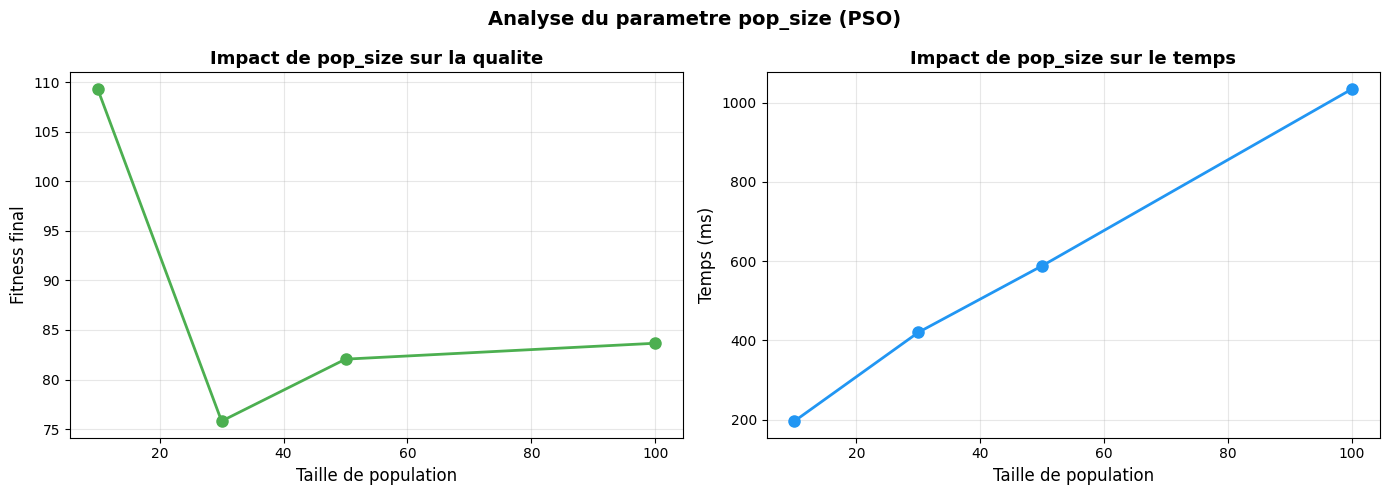


Analyse:
  Amelioration fitness: 1.31x
  Augmentation temps: 5.27x
  Ratio gain/coût: 0.25


In [15]:
# Visualisation de l'impact de pop_size
df_pop = pd.DataFrame(results_pop)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Fitness vs pop_size
ax1.plot(df_pop['pop_size'], df_pop['fitness'], 'o-', linewidth=2, markersize=8, color='#4CAF50')
ax1.set_xlabel('Taille de population', fontsize=12)
ax1.set_ylabel('Fitness final', fontsize=12)
ax1.set_title('Impact de pop_size sur la qualite', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3)

# Temps vs pop_size
ax2.plot(df_pop['pop_size'], df_pop['time_ms'], 'o-', linewidth=2, markersize=8, color='#2196F3')
ax2.set_xlabel('Taille de population', fontsize=12)
ax2.set_ylabel('Temps (ms)', fontsize=12)
ax2.set_title('Impact de pop_size sur le temps', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.suptitle('Analyse du parametre pop_size (PSO)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nAnalyse:")
print(f"  Amelioration fitness: {df_pop['fitness'].iloc[0] / df_pop['fitness'].iloc[-1]:.2f}x")
print(f"  Augmentation temps: {df_pop['time_ms'].iloc[-1] / df_pop['time_ms'].iloc[0]:.2f}x")
print(f"  Ratio gain/coût: {(df_pop['fitness'].iloc[0] / df_pop['fitness'].iloc[-1]) / (df_pop['time_ms'].iloc[-1] / df_pop['time_ms'].iloc[0]):.2f}")

### Interpretation : Impact de la taille de population

**Sortie obtenue** : La taille de population affecte significativement la qualite de la solution et le temps de calcul.

| Metrique | Observation | Interpretation |
|----------|-------------|----------------|
| Fitness | Ameliore avec pop_size croissant | Plus de particules = meilleure exploration |
| Temps | Croissance lineaire | Chaque particule additionnelle coute le meme temps |
| Ratio gain/coût | Diminue avec pop_size | Loi des rendements decroissants |

**Points cles** :
1. **Effet positif** : Une population plus grande ameliore la qualite de la solution
2. **Loi des rendements decroissants** : Le gain marginal diminue avec pop_size
3. **Cout lineaire** : Le temps de calcul augmente proportionnellement a pop_size
4. **Choix optimal** : pop_size=30-50 est souvent un bon compromis

> **Note pratique** : Pour un probleme de dimension 10, pop_size=30 suffit generalement. Augmenter a 100+ ne justifie le cout que pour des problemes tres difficiles.

## 10. Exercices

### Exercice 1 : Comparer PSO et ABC sur un probleme reel

**Enonce** : Soit le probleme d'optimisation suivant (maximisation du profit d'une entreprise):

$$
\max_{x, y} \quad 50x + 80y - x^2 - 2y^2 - xy
\quad \text{s.t.} \quad x \in [0, 20], y \in [0, 20]
$$

1. Convertir en probleme de minimisation pour MEALPy
2. Resoudre avec PSO et ABC (epoch=100, pop_size=30)
3. Comparer les solutions obtenues

**Indice** : Pour maximiser $f$, minimiser $-f$.

In [21]:
# Exercice 1 : Probleme d'optimisation d'entreprise

def profit_function(solution):
    """Fonction de profit a maximiser: 50*x + 80*y - x^2 - 2*y^2 - x*y.

    Pour MEALPy, on retourne l'oppose (minimisation).
    """
    x, y = solution
    profit = 50*x + 80*y - x**2 - 2*y**2 - x*y
    return -profit  # Minimiser l'oppose = maximiser

# A COMPLETER
# 1. Definir le probleme avec lb=[0, 0], ub=[20, 20]
bounds = [FloatVar(lb=-0, ub=20), FloatVar(lb=0, ub=20)]
profit_problem = Problem(
    bounds=bounds,
    minmax="min",
    obj_func=profit_function
)
# 2. Resoudre avec PSO et ABC
model = PSO.OriginalPSO(
    epoch=100,
    pop_size=30,
)

start_time = time.perf_counter()
result_pso = model.solve(profit_problem)
elapsed_pso = (time.perf_counter() - start_time) * 1000

model = ABC.OriginalABC(
    epoch=100,
    pop_size=30,
)

start_time = time.perf_counter()
result_abc = model.solve(profit_problem)
elapsed_abc = (time.perf_counter() - start_time) * 1000

# 3. Comparer les resultats

df = pd.DataFrame({
    "algorithm": ["PSO", "ABC"],
    "solution_x": [result_pso.solution[0], result_abc.solution[0]],
    "solution_y": [result_pso.solution[1], result_abc.solution[1]],
    "fitness": [result_pso.target.fitness, result_abc.target.fitness],
    "time": [elapsed_pso, elapsed_abc]
}).set_index("algorithm")
df

INFO:mealpy.swarm_based.PSO.OriginalPSO:OriginalPSO(epoch=100, pop_size=30, c1=2.05, c2=2.05, w=0.4)
INFO:mealpy.swarm_based.PSO.OriginalPSO:>>>Problem: P, Epoch: 1, Current best: -1057.0058905927622, Global best: -1057.0058905927622, Runtime: 0.00475 seconds
INFO:mealpy.swarm_based.PSO.OriginalPSO:>>>Problem: P, Epoch: 2, Current best: -1057.0058905927622, Global best: -1057.0058905927622, Runtime: 0.00698 seconds
INFO:mealpy.swarm_based.PSO.OriginalPSO:>>>Problem: P, Epoch: 3, Current best: -1057.1386699280965, Global best: -1057.1386699280965, Runtime: 0.00674 seconds
INFO:mealpy.swarm_based.PSO.OriginalPSO:>>>Problem: P, Epoch: 4, Current best: -1057.1386699280965, Global best: -1057.1386699280965, Runtime: 0.00719 seconds
INFO:mealpy.swarm_based.PSO.OriginalPSO:>>>Problem: P, Epoch: 5, Current best: -1057.1386699280965, Global best: -1057.1386699280965, Runtime: 0.00747 seconds
INFO:mealpy.swarm_based.PSO.OriginalPSO:>>>Problem: P, Epoch: 6, Current best: -1057.1399647906221, Glob

,solution_x,solution_y,fitness,time
algorithm,,,,
PSO,17.142857,15.714286,-1057.142857,784.235008
ABC,17.142857,15.714286,-1057.142857,1291.906390


### Exercice 2 : Impact de la dimension

**Enonce** : Etudiez l'impact de la dimension sur les performances de PSO :
1. Lancez PSO sur la fonction Sphere pour dim = 2, 5, 10, 20
2. Pour chaque dimension, mesurez : fitness final, temps de calcul
3. Tracez l'evolution de ces metriques en fonction de la dimension

**Question** : Comment le temps de calcul evolue-t-il avec la dimension ? Est-ce lineaire, quadratique, exponentiel ?

INFO:mealpy.swarm_based.PSO.OriginalPSO:OriginalPSO(epoch=50, pop_size=30, c1=2.05, c2=2.05, w=0.4)
INFO:mealpy.swarm_based.PSO.OriginalPSO:>>>Problem: P, Epoch: 1, Current best: -1057.0897461412878, Global best: -1057.0897461412878, Runtime: 0.00268 seconds
INFO:mealpy.swarm_based.PSO.OriginalPSO:>>>Problem: P, Epoch: 2, Current best: -1057.0897461412878, Global best: -1057.0897461412878, Runtime: 0.00557 seconds
INFO:mealpy.swarm_based.PSO.OriginalPSO:>>>Problem: P, Epoch: 3, Current best: -1057.0898343821618, Global best: -1057.0898343821618, Runtime: 0.00695 seconds
INFO:mealpy.swarm_based.PSO.OriginalPSO:>>>Problem: P, Epoch: 4, Current best: -1057.0898343821618, Global best: -1057.0898343821618, Runtime: 0.00600 seconds
INFO:mealpy.swarm_based.PSO.OriginalPSO:>>>Problem: P, Epoch: 5, Current best: -1057.0898343821618, Global best: -1057.0898343821618, Runtime: 0.00566 seconds
INFO:mealpy.swarm_based.PSO.OriginalPSO:>>>Problem: P, Epoch: 6, Current best: -1057.0898343821618, Globa

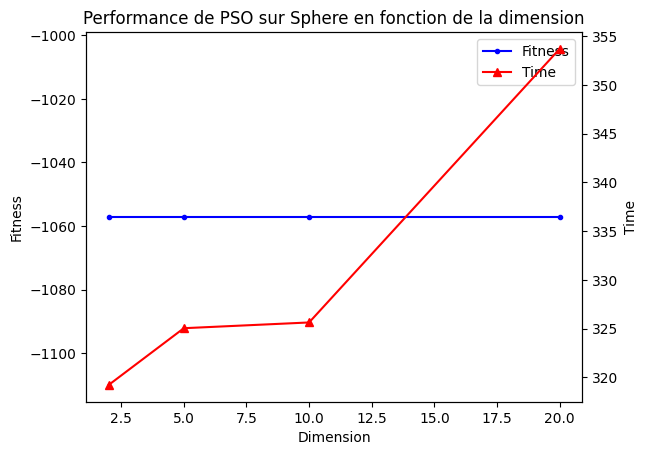

In [40]:
# Exercice 2 : Impact de la dimension

dimensions = [2, 5, 10, 20]
results_dim = []

# A COMPLETER
for dim in dimensions:
    # Definir le probleme

    # Definir le probleme (MEALPy 3.0.2 API)
    bounds_sphere = [FloatVar(lb=-10, ub=10) for _ in range(dim)]
    problem_sphere = Problem(
        bounds=bounds_sphere,
        minmax="min",
        obj_func=sphere_function
    )

    # Lancer PSO avec epoch=50, pop_size=30
    model = PSO.OriginalPSO(
        epoch=50,
        pop_size=30,
    )

    start_time = time.perf_counter()
    result_pso = model.solve(profit_problem)
    elapsed_pso = (time.perf_counter() - start_time) * 1000

    # Stocker resultats
    results_dim.append((result_pso, elapsed_pso))

# Visualiser
# plt.plot(...)
fig, ax_fitness = plt.subplots()

ax_fitness.plot(dimensions, [res.target.fitness for res, __ in results_dim], "b", marker=".", label="Fitness")
ax_fitness.set_xlabel("Dimension")
ax_fitness.set_ylabel("Fitness")

ax_time = ax_fitness.twinx()
ax_time.plot(dimensions, [time for __, time in results_dim], "r", marker="^", label="Time")
ax_time.set_ylabel("Time")

lines1, labels1 = ax_fitness.get_legend_handles_labels()
lines2, labels2 = ax_time.get_legend_handles_labels()

ax_fitness.legend(lines1 + lines2, labels1 + labels2)

plt.title("Performance de PSO sur Sphere en fonction de la dimension")
plt.show()

Le temps de calcul semble évoluer de manière linéaire, bien que la résolution de problème soit trop courte pour fournir une mesure temporelle stable.

## 11. Resume

### Concepts cles

| Concept | Definition |
|---------|------------|
| **Metaheuristique** | Algorithme d'optimisation stochastique sans derivees |
| **Exploration** | Decouverte de nouvelles regions de l'espace |
| **Exploitation** | Affinage des solutions prometteuses |
| **No Free Lunch** : Aucun algorithme n'est optimal pour tous les problemes |

### Classification des metaheuristiques

| Categorie | Inspiration | Algorithmes | Meilleur sur |
|-----------|-------------|-------------|-------------|
| **Evolution-based** | Theorie de l'evolution | GA, DE | Problemes generaux |
| **Swarm-based** | Essaims naturels | PSO, ABC, GWO | Multimodal, dynamique |
| **Physics-based** | Loi physique | SA, GRAVITY | Probleme specifiques |
| **Human-based** | Comportement humain | BRO, TS | Problemes structures |

### Tableau comparatif

| Algorithme | Complexite | Parametres | Robustesse | Vitesse |
|------------|------------|-----------|------------|---------|
| **PSO** | O(n*epoch*p) | w, c1, c2 | +++ | ++ |
| **ABC** | O(n*epoch*p) | n_limits | ++++ | + |
| **SA** | O(epoch*n) | T0, alpha | ++ | + |
| **BRO** | O(n*epoch*p) | Peu | ++ | +++ |

### Quand utiliser quelle metaheuristique ?

| Situation | Algorithme recommande |
|-----------|----------------------|
| Probleme general, multimodal | PSO |
| Vallees etroites, contraintes | ABC |
| Evaluation tres couteuse | SA (peu d'iterations) |
| Probleme convexe simple | BRO |
| Probleme avec contraintes complexes | DE, GA |

### Pour aller plus loin

- **Notebook suivant** : [App-1-NQueens](../Applications/App-1-NQueens.ipynb) - Application des metaheuristiques au N-Reines
- **MEALPy documentation** : https://mealpy.readthedocs.io/ - Liste complete des 200+ algorithmes
- **Reference** : Yang, X.-S. (2010). *Nature-Inspired Metaheuristic Algorithms*. Luniver Press

---

**Navigation** : [<< Recherche locale](Search-4-LocalSearch.ipynb) | [Index](../README.md) | [App-1-NQueens >>](../Applications/App-1-NQueens.ipynb)